# Face Detection with Haar Cascade

This notebook shows a simple face detector using OpenCV's Haar Cascade classifier.

**Steps:**
1. Load image
2. Convert to grayscale
3. Detect faces
4. Draw boxes

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

## Load Haar Cascade

OpenCV ships with pre-trained cascade files. We'll use the frontal face cascade that comes with OpenCV.

In [2]:
#cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
cascade_path = "./haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise RuntimeError("Failed to load Haar cascade.")

print("Cascade loaded:", cascade_path)

Cascade loaded: ./haarcascade_frontalface_default.xml


## Load an Image

Replace the path below with your image file.

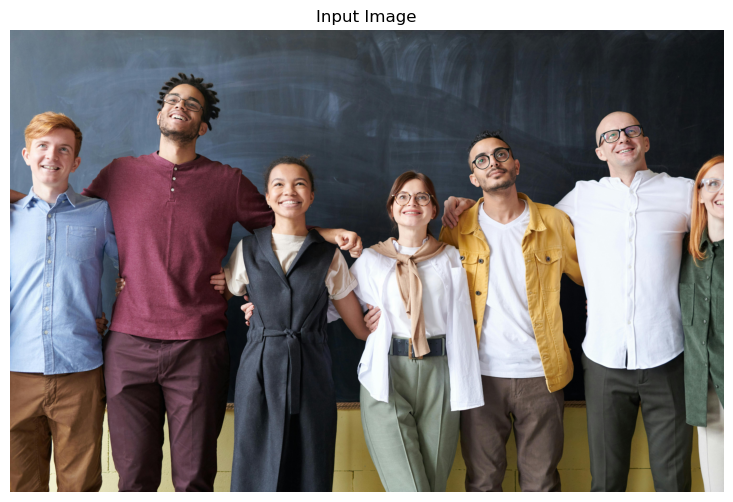

In [3]:
image_path = "img/image.png"  # TODO: update this
image_bgr = cv2.imread(image_path)

if image_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Input Image")
plt.axis("off")
plt.show()

## Detect Faces

Faces detected: 20


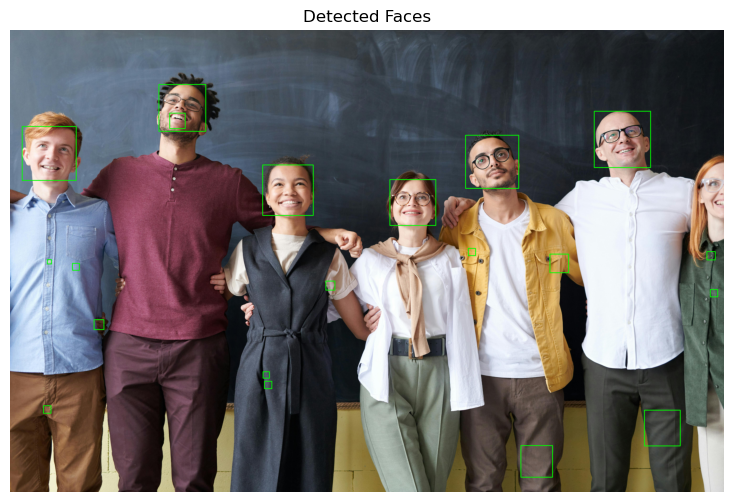

In [5]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print(f"Faces detected: {len(faces)}")

# Draw boxes
output = image_bgr.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 5)

# Show result
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.imshow(output_rgb)
plt.title("Detected Faces")
plt.axis("off")
plt.show()

## Real-time Face Detection from Camera

Detect faces in live video stream from webcam. Press 'q' to quit, 's' to save frame.

In [6]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Cannot open camera")
else:
    frame_count = 0
    saved_count = 0
    
    print("Starting webcam... Press 'q' to quit, 's' to save frame")
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            print("Error: Cannot read frame")
            break
        
        frame_count += 1
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(30, 30)
        )
        
        # Draw rectangles around faces
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Display info
        cv2.putText(frame, f"Faces: {len(faces)}", (10, 30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(frame, "Press 'q' to quit, 's' to save", (10, 70), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1)
        
        # Show frame
        cv2.imshow("Face Detection", frame)
        
        # Handle key press
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):  # Press 'q' to quit
            print("Exiting...")
            break
        elif key == ord('s'):  # Press 's' to save
            filename = f"face_detection_{saved_count}.jpg"
            cv2.imwrite(filename, frame)
            saved_count += 1
            print(f"Frame saved: {filename}")
    
    cap.release()
    cv2.destroyAllWindows()
    print(f"Total frames processed: {frame_count}, Saved: {saved_count}")

Starting webcam... Press 'q' to quit, 's' to save frame
Exiting...
Total frames processed: 489, Saved: 0
